In [36]:
import numpy as np

In [37]:
data = np.load('marmousi_Ip_model.npy')

In [38]:
data.shape

(1, 13601, 2801)

In [39]:
data1 = np.load('marmousi_synthetic_seismic.npy')

In [40]:
data1.shape

(1, 2721, 701)

In [41]:
import numpy as np
import matplotlib.pyplot as plt

def plot_marmousi(Ip, seismic,
                  cmap_model='jet', cmap_seismic='gray_r',
                  figsize=(12, 6)):
    """
    可视化 Marmousi2 的阻抗模型与地震记录。
    
    参数
    ----
    ip_path : str
        marmousi_Ip_model.npy 的路径
    seismic_path : str
        marmousi_synthetic_seismic.npy 的路径
    cmap_model : str
        地质模型的颜色映射（默认 'jet'）
    cmap_seismic : str
        地震记录的颜色映射（默认 'gray_r'）
    figsize : tuple
        图像尺寸
    """
    # 去掉通道维
    Ip = Ip[0,0]          # [X, Z]
    seismic = seismic[0,0]  # [T, R]

    # 转置模型：让深度向下
    Ip_vis = Ip.T        # [Z, X]
    
    # ---------------------- 绘图 ----------------------
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ---- 地质模型 ----
    im1 = axes[0].imshow(Ip_vis, cmap=cmap_model, aspect='auto',
                         origin='upper')
    axes[0].set_title("Marmousi2 Impedance Model", fontsize=13)
    axes[0].set_xlabel("Horizontal distance (samples)")
    axes[0].set_ylabel("Depth (samples)")
    plt.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04,
                 label="P-wave impedance")

    # ---- 地震记录 ----
    im2 = axes[1].imshow(seismic, cmap=cmap_seismic, aspect='auto',
                         origin='upper')
    axes[1].set_title("Synthetic Seismic Data", fontsize=13)
    axes[1].set_xlabel("Receiver index")
    axes[1].set_ylabel("Time sample")
    plt.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04,
                 label="Amplitude")

    plt.tight_layout()
    plt.show()

In [42]:
plot_marmousi("marmousi_Ip_model.npy", "marmousi_synthetic_seismic.npy")

TypeError: string indices must be integers

1, 2710, 701 -> 128, 70, 70 -> 1, 70, 70  本质上可以看成一种划分块

数据增强

1, 13601, 2801

1, 1000, 350

2, 70, 70

In [ ]:
import torch.nn.functional as F
import torch

In [ ]:
t1 = torch.from_numpy(data1).unsqueeze(0)
t2 = torch.from_numpy(data).unsqueeze(0)

In [ ]:
t1.shape

torch.Size([1, 1, 2721, 701])

In [ ]:
t2.shape

torch.Size([1, 1, 13601, 2801])

In [ ]:
data2 = F.interpolate(t1, t2.shape[2:], mode='bilinear', align_corners=True)

In [ ]:
data2.shape

torch.Size([1, 1, 13601, 2801])

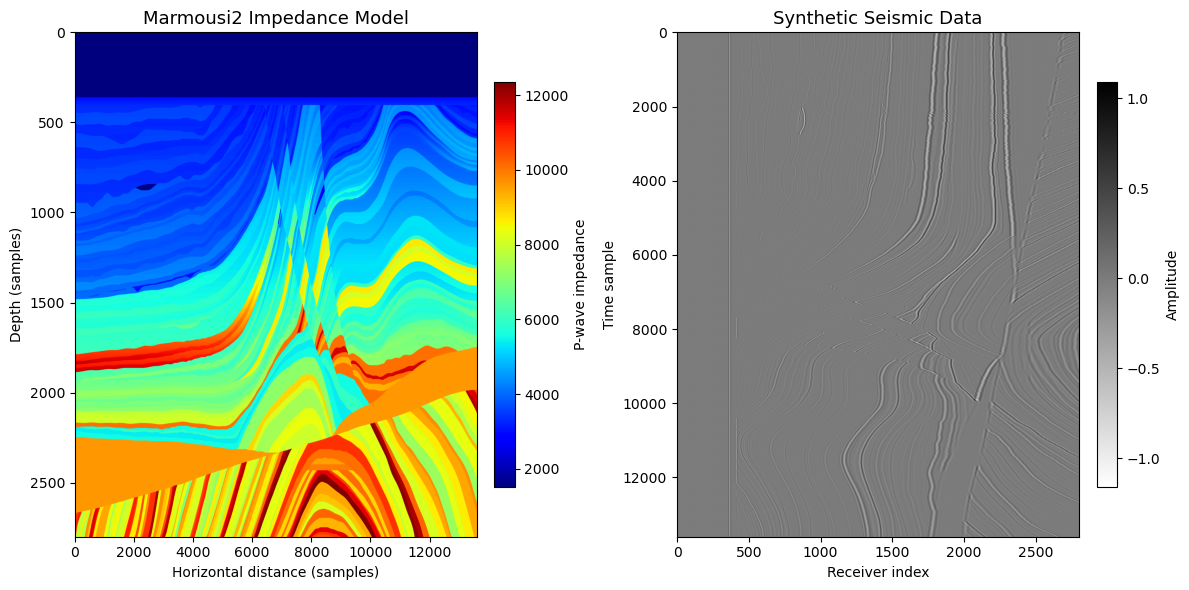

In [ ]:
plot_marmousi(t2, data2)

In [44]:
data2.shape

torch.Size([1, 1, 13601, 2801])

In [47]:
t1.shape

torch.Size([1, 1, 2721, 701])

In [ ]:
import torch
import torch.nn.functional as F

# ---- 超参数（与上面的整除推导严格一致） ----
WIN_H, WIN_W = 1000, 350
HALO_H, HALO_W = 200, 25
CORE_H, CORE_W = WIN_H - 2*HALO_H, WIN_W - 2*HALO_W    # 600, 300
OUT_CORE_H, OUT_CORE_W = 42, 60                         # 由 70x70 核心映射推导
UP_H, UP_W = 5, 4                                       # 全局目标放大
STRIDE_H, STRIDE_W = CORE_H, CORE_W                     # 600, 300

def hanning2d(h, w, device):
    wy = torch.hann_window(h, periodic=False, device=device)
    wx = torch.hann_window(w, periodic=False, device=device)
    return (wy[:, None] * wx[None, :]).clamp_min(1e-4)[None,None,:,:]  # [1,1,h,w]

def tile_starts(L, win, stride):
    pos = list(range(0, max(1, L - win + 1), stride))
    if pos[-1] + win < L:
        pos.append(L - win)
    return pos

@torch.no_grad()
def infer_marmousi_mosaic(x, model, device='cuda'):
    """
    x: [1,1,2721,701] 原始波形
    model: 输入 [B,1,1000,350] → 输出 [B,1,70,70]
    返回: [1,1,13601,2801]
    """
    x = x.to(device)
    _, _, H, W = x.shape

    Y = torch.zeros((1,1,H*UP_H, W*UP_W), device=device)
    M = torch.zeros_like(Y)

    # 平滑权重（作用在上采后的 (CORE_H*UP_H, CORE_W*UP_W)）
    Wcore = hanning2d(CORE_H*UP_H, CORE_W*UP_W, device)

    ys = tile_starts(H, WIN_H, STRIDE_H)
    xs = tile_starts(W, WIN_W, STRIDE_W)

    for y0 in ys:
        for x0 in xs:
            y1, x1 = y0 + WIN_H, x0 + WIN_W

            # 反射填充以取到完整 tile
            patch = x[:, :, max(0,y0):min(H,y1), max(0,x0):min(W,x1)]
            pad_top    = max(0, -y0)
            pad_left   = max(0, -x0)
            pad_bottom = max(0, y1 - H)
            pad_right  = max(0, x1 - W)
            patch = F.pad(patch, (pad_left, pad_right, pad_top, pad_bottom), mode='reflect')
            assert patch.shape[-2:] == (WIN_H, WIN_W)

            # 模型前向：[1,1,1000,350] → [1,1,70,70]
            pred70 = model(patch)

            # 裁出 70×70 的“核心输出”：各向去掉 t_h=14, t_w=5
            pred_core = pred70[:, :, 14:70-14, 5:70-5]   # [1,1,42,60]

            # 各向异性上采样到 (CORE_H*UP_H, CORE_W*UP_W) = (3000, 1200)
            pred_up = F.interpolate(pred_core, size=(CORE_H*UP_H, CORE_W*UP_W),
                                    mode='bilinear', align_corners=False)

            # 放置坐标（输出坐标系）：核心输入左上的 (y0+HALO_H, x0+HALO_W) 放大 (5,4)
            y_out = (y0 + HALO_H) * UP_H
            x_out = (x0 + HALO_W) * UP_W

            # Overlap-Add
            Y[:, :, y_out:y_out+CORE_H*UP_H, x_out:x_out+CORE_W*UP_W] += pred_up * Wcore
            M[:, :, y_out:y_out+CORE_H*UP_H, x_out:x_out+CORE_W*UP_W] += Wcore

    Y = Y / (M + 1e-6)
    # 统一裁剪到精确 size
    Y = Y[:, :, :13601, :2801]
    return Y

In [46]:
import math
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# === 你的 Marmousi 输入与分块参数（可改） ===
WIN_H, WIN_W = 1000, 350        # 输入 tile 尺寸（含 halo）
HALO_H, HALO_W = 200, 25        # halo（与前文整除映射一致）
CORE_H, CORE_W = WIN_H-2*HALO_H, WIN_W-2*HALO_W  # 600, 300
STRIDE_H, STRIDE_W = CORE_H, CORE_W              # 600, 300

def _tile_starts(L, win, stride):
    """一维滑窗起点列表，保证覆盖到末尾（不足用最后一窗对齐末端）"""
    starts = list(range(0, max(1, L - win + 1), stride))
    if starts[-1] + win < L:
        starts.append(L - win)
    return starts

def _reflect_pad_slice(x, y0, x0, win_h, win_w):
    """
    从 x[..., H, W] 中以反射填充的方式取 [win_h, win_w] patch。
    返回 patch 以及实际 pad 的四边大小（调试可用）。
    """
    _, _, H, W = x.shape
    y1, x1 = y0 + win_h, x0 + win_w
    patch = x[:, :, max(0,y0):min(H,y1), max(0,x0):min(W,x1)]
    pad_top    = max(0, -y0)
    pad_left   = max(0, -x0)
    pad_bottom = max(0, y1 - H)
    pad_right  = max(0, x1 - W)
    if any(v > 0 for v in (pad_left, pad_right, pad_top, pad_bottom)):
        patch = F.pad(patch, (pad_left, pad_right, pad_top, pad_bottom), mode='reflect')
    return patch, (pad_top, pad_bottom, pad_left, pad_right)

def generate_tiles(x, win_h=WIN_H, win_w=WIN_W, halo_h=HALO_H, halo_w=HALO_W):
    """
    生成器：按 row-major 顺序返回每个 tile 的信息。
    输入:
        x: torch.Tensor, [1,1,H,W]
    产出:
        dict {
          'idx': 序号,
          'y0','x0': 输入图上的左上角坐标（含 halo 的窗）,
          'patch': torch.Tensor [1,1,win_h,win_w],
          'core_slices': (y_core0, y_core1, x_core0, x_core1) —— 在 patch 内的核心区切片
        }
    """
    assert x.ndim == 4 and x.shape[0] == 1 and x.shape[1] == 1, "期望 x 形状为 [1,1,H,W]"
    _, _, H, W = x.shape
    stride_h, stride_w = win_h - 2*halo_h, win_w - 2*halo_w
    ys = _tile_starts(H, win_h, stride_h)
    xs = _tile_starts(W, win_w, stride_w)

    idx = 0
    for y0 in ys:
        for x0 in xs:
            patch, _ = _reflect_pad_slice(x, y0, x0, win_h, win_w)
            y_core0, y_core1 = halo_h, win_h - halo_h
            x_core0, x_core1 = halo_w, win_w - halo_w
            yield {
                'idx': idx,
                'y0': y0, 'x0': x0,
                'patch': patch,  # [1,1,win_h,win_w]
                'core_slices': (y_core0, y_core1, x_core0, x_core1),
            }
            idx += 1

def plot_tiles_grid(x, win_h=WIN_H, win_w=WIN_W, halo_h=HALO_H, halo_w=HALO_W,
                    max_cols=8, figsize_per_subplot=(2.6, 2.6), show_core_box=True,
                    tight_layout=True):
    """
    对输入进行分块并按扫描顺序绘制所有 tile 到一个大图网格中。
    参数:
        x: torch.Tensor, [1,1,H,W]
        max_cols: 子图每行最多列数
        figsize_per_subplot: 每个子图的尺寸 (w, h) (英寸)
        show_core_box: 是否在每个子图标出核心区矩形框（去 halo 的中心区域）
    返回:
        fig, axes
    """
    device = x.device
    tiles = list(generate_tiles(x, win_h, win_w, halo_h, halo_w))
    n = len(tiles)
    if n == 0:
        raise ValueError("没有生成任何 tile，请检查参数。")

    n_cols = min(max_cols, n)
    n_rows = math.ceil(n / n_cols)
    fig_w = figsize_per_subplot[0] * n_cols
    fig_h = figsize_per_subplot[1] * n_rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_w, fig_h))
    if isinstance(axes, np.ndarray):
        axes = axes.reshape(-1)
    else:
        axes = np.array([axes])

    for i, tile in enumerate(tiles):
        ax = axes[i]
        patch = tile['patch'][0,0].detach().float().cpu().numpy()
        ax.imshow(patch, origin='upper', aspect='auto')  # 不指定 cmap，保持默认
        ax.set_title(f"#{tile['idx']}  y0={tile['y0']}, x0={tile['x0']}", fontsize=9)
        ax.axis('off')

        if show_core_box:
            y0c, y1c, x0c, x1c = tile['core_slices']
            # 在子图上画核心区边框（默认边框风格）
            rect = plt.Rectangle((x0c, y0c),
                                 x1c - x0c,
                                 y1c - y0c,
                                 fill=False, linewidth=1.0)
            ax.add_patch(rect)

    # 把多出来的空子图关掉
    for j in range(n, len(axes)):
        axes[j].axis('off')

    if tight_layout:
        plt.tight_layout()
    return fig, axes

# ======== 使用示例 ========
# 假设你有原始输入 x，形状 [1,1,2721,701]，torch.Tensor
# x = torch.from_numpy(np.random.randn(1,1,2721,701).astype(np.float32))  # 示例
# fig, axes = plot_tiles_grid(x, max_cols=6)
# plt.show()

(<Figure size 2080x520 with 16 Axes>,
 array([<Axes: title={'center': '#0  y0=0, x0=0'}>,
        <Axes: title={'center': '#1  y0=0, x0=300'}>,
        <Axes: title={'center': '#2  y0=0, x0=351'}>,
        <Axes: title={'center': '#3  y0=600, x0=0'}>,
        <Axes: title={'center': '#4  y0=600, x0=300'}>,
        <Axes: title={'center': '#5  y0=600, x0=351'}>,
        <Axes: title={'center': '#6  y0=1200, x0=0'}>,
        <Axes: title={'center': '#7  y0=1200, x0=300'}>,
        <Axes: title={'center': '#8  y0=1200, x0=351'}>,
        <Axes: title={'center': '#9  y0=1721, x0=0'}>,
        <Axes: title={'center': '#10  y0=1721, x0=300'}>,
        <Axes: title={'center': '#11  y0=1721, x0=351'}>, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >], dtype=object))

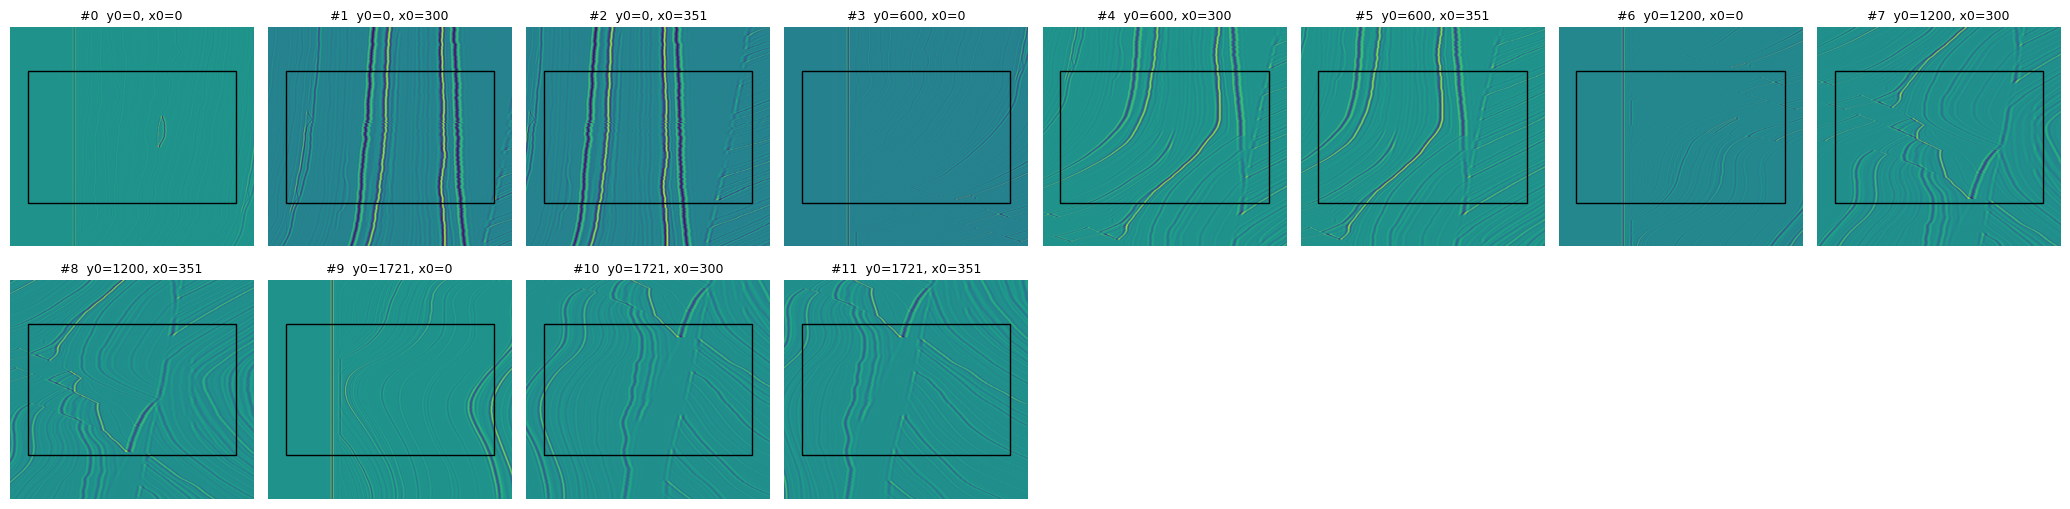

In [48]:
plot_tiles_grid(t1)

In [49]:
t1.shape

torch.Size([1, 1, 2721, 701])

In [50]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np
import torch.nn.functional as F

def visualize_tile_layout_on_image(
    x,
    win_h=1000, win_w=350,
    halo_h=200, halo_w=25,
    alpha=0.35,
    show_core=True,
    show_index=True,
    cmap='gray'
):
    """
    在原图上可视化分块布局。
    参数：
        x: torch.Tensor, [1,1,H,W] 输入波形
        win_h, win_w: 每个tile大小
        halo_h, halo_w: halo大小
        alpha: tile覆盖的透明度
        show_core: 是否显示去掉halo后的核心区域
        show_index: 是否在tile中心显示编号
        cmap: 背景色图
    """
    x = x.detach().cpu()
    _, _, H, W = x.shape
    stride_h = win_h - 2 * halo_h
    stride_w = win_w - 2 * halo_w

    # 计算分块起点
    def _starts(L, win, stride):
        starts = list(range(0, max(1, L - win + 1), stride))
        if starts[-1] + win < L:
            starts.append(L - win)
        return starts

    ys = _starts(H, win_h, stride_h)
    xs = _starts(W, win_w, stride_w)

    # 背景
    img = x[0, 0].numpy()
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(img, cmap=cmap, origin='upper', aspect='auto')

    # 绘制分块
    colors = plt.cm.tab20(np.linspace(0, 1, len(ys)*len(xs)))
    idx = 0
    for y0 in ys:
        for x0 in xs:
            color = colors[idx % len(colors)]
            rect = patches.Rectangle(
                (x0, y0), win_w, win_h,
                linewidth=1.5, edgecolor=color, facecolor=color, alpha=alpha
            )
            ax.add_patch(rect)

            # 核心区
            if show_core:
                core_rect = patches.Rectangle(
                    (x0 + halo_w, y0 + halo_h),
                    win_w - 2 * halo_w,
                    win_h - 2 * halo_h,
                    linewidth=1.2, edgecolor='black',
                    facecolor='none', linestyle='--'
                )
                ax.add_patch(core_rect)

            if show_index:
                ax.text(
                    x0 + win_w / 2,
                    y0 + win_h / 2,
                    str(idx),
                    ha='center', va='center',
                    fontsize=9, color='black', weight='bold'
                )
            idx += 1

    ax.set_xlim([0, W])
    ax.set_ylim([H, 0])
    ax.set_title(f"Tile layout visualization ({len(ys)*len(xs)} patches)")
    plt.tight_layout()
    plt.show()

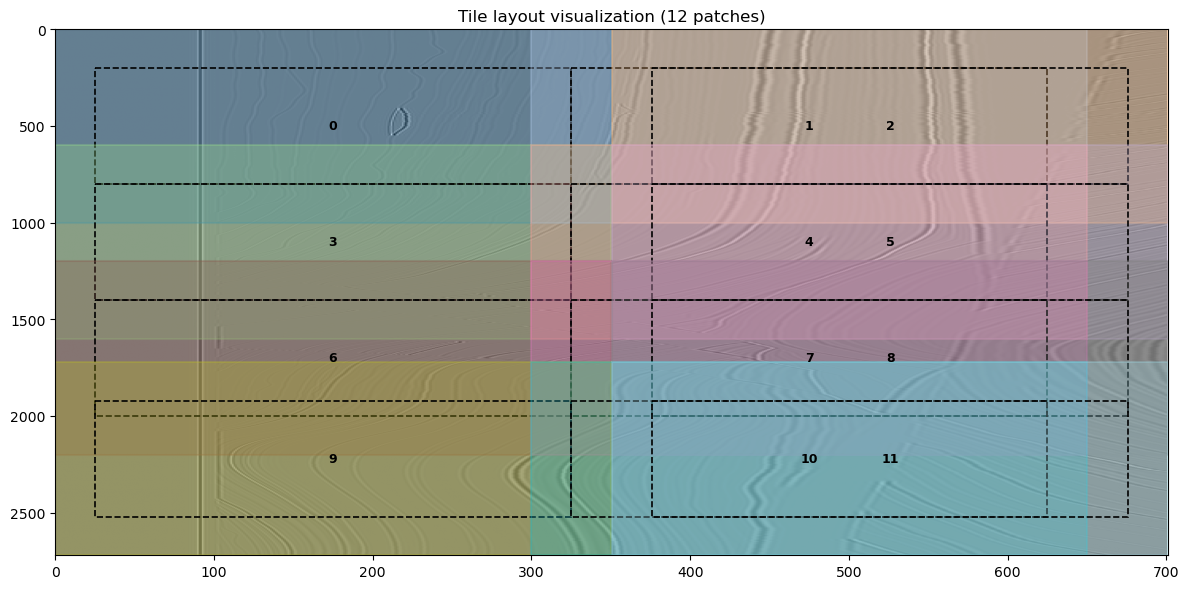

In [51]:
visualize_tile_layout_on_image(
    t1,
    win_h=1000, win_w=350,
    halo_h=200, halo_w=25,
    alpha=0.3,
    show_core=True,
    show_index=True
)

In [ ]:
3500, 700
1000, 350